# 11b — Hyperparameter Tuning & Model Optimization
## Objective

This notebook performs hyperparameter tuning and model optimization for the participant-level machine learning models developed during Week 4.

Using the processed multimodal datasets and the shared participant-level validation strategy, baseline Logistic Regression, Random Forest, and XGBoost models are optimized using GridSearchCV. The notebook compares baseline and tuned performance, evaluates different probability thresholds (0.50, 0.40, and 0.30), and identifies the strongest model candidates for subsequent multimodal evaluation.

All outputs are exported to the project output structure to support technical reporting and final model selection.

## 1. Libraries and Project Paths

In [1]:
# =============================================================================
# Libraries
# =============================================================================

from pathlib import Path
import sys
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
)

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from xgboost import XGBClassifier

In [2]:
# =============================================================================
# Locate project root
# =============================================================================

cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the src directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
# =============================================================================
# Shared modeling utilities
# =============================================================================

from src.modeling import outputs
from src.modeling import tuning

from src.modeling.models import (
    get_logistic_regression,
    get_random_forest,
    get_xgboost,
)
from src.modeling.evaluation import (
    evaluate_model,
)


In [4]:
# =============================================================================
# Define project directories
# =============================================================================

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"

METRICS_DIR = OUTPUTS_DIR / "metrics"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for directory in [
    METRICS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Metrics directory: {METRICS_DIR}")
print(f"Tables directory: {TABLES_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease
Processed data: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed
Metrics directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\metrics
Tables directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables
Figures directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures


The required Python libraries, project directories, and shared modeling utilities are imported. The notebook automatically locates the project root and initializes the processed data and output directories used throughout the project.

The shared modeling modules developed during previous project stages are imported to ensure consistency across all modeling experiments. These reusable utilities provide standardized model definitions, evaluation functions, hyperparameter tuning procedures, and output management, allowing the optimization experiments performed in this notebook to follow the same implementation framework used throughout the project.

## 2. Hyperparameter Tuning Configuration

In [5]:
# =============================================================================
# Hyperparameter tuning configuration
# =============================================================================

RANDOM_STATE = 42

N_SPLITS = 5

THRESHOLDS = [
    0.50,
    0.40,
    0.30,
]

TARGET_COLUMN = "label"
PARTICIPANT_ID_COLUMN = "patient_id"

DATASETS = {
    "Demographics + Questionnaire": "demographics_questionnaire.csv",
    "Wearable + Questionnaire": "wearable_questionnaire.csv",
    "Multimodal": "multimodal_full.csv",
}

MODELS = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
]

print(f"Random state: {RANDOM_STATE}")
print(f"Cross-validation folds: {N_SPLITS}")
print(f"Probability thresholds: {THRESHOLDS}")

print("\nDatasets:")
for name in DATASETS:
    print(f"- {name}")

print("\nModels:")
for model in MODELS:
    print(f"- {model}")

Random state: 42
Cross-validation folds: 5
Probability thresholds: [0.5, 0.4, 0.3]

Datasets:
- Demographics + Questionnaire
- Wearable + Questionnaire
- Multimodal

Models:
- Logistic Regression
- Random Forest
- XGBoost


The global hyperparameter tuning configuration is defined before model optimization. A fixed random seed is used to ensure reproducibility across all experiments, while five-fold stratified cross-validation is adopted to maintain consistent class distributions during model optimization.

Three participant-level datasets are included in the optimization process: the demographics plus questionnaire dataset, the wearable plus questionnaire dataset, and the complete multimodal dataset. Logistic Regression, Random Forest, and XGBoost are evaluated using the same validation strategy to enable consistent comparison across all modeling approaches. In addition, multiple probability thresholds are specified for subsequent threshold analysis following the project supervisor's recommendation.

## 3. Load Integrated Datasets

In [6]:
# Define processed datasets

dataset_paths = {
    "Demographics + Questionnaire":
        PROCESSED_DIR / "demographics_questionnaire.csv",
    "Wearable + Questionnaire":
        PROCESSED_DIR / "wearable_questionnaire.csv",
    "Multimodal":
        PROCESSED_DIR / "multimodal_full.csv",
}
# Verify dataset availability

for dataset_name, dataset_path in dataset_paths.items():
    assert dataset_path.exists(), (
        f"Dataset not found: {dataset_path}"
    )
print("All processed datasets were found.")

All processed datasets were found.


In [7]:
# Load participant-level datasets
datasets = {}
for dataset_name, dataset_path in dataset_paths.items():
    datasets[dataset_name] = pd.read_csv(
        dataset_path,
        dtype={
            PARTICIPANT_ID_COLUMN: str,
        },
    )
print("Datasets successfully loaded.")

Datasets successfully loaded.


In [8]:
# Dataset overview
dataset_summary = []
for dataset_name, dataset in datasets.items():
    dataset_summary.append({
        "Dataset": dataset_name,
        "Participants":
            dataset[PARTICIPANT_ID_COLUMN].nunique(),
        "Rows":
            len(dataset),
        "Columns":
            dataset.shape[1],
        "Target Classes":
            dataset[TARGET_COLUMN].nunique(),
    })
dataset_summary = pd.DataFrame(dataset_summary)
display(dataset_summary)

,Dataset,Participants,Rows,Columns,Target Classes
0,Demographics + Questionnaire,469,469,53,3
1,Wearable + Questionnaire,469,469,226,3
2,Multimodal,469,469,235,3


In [9]:
# Display first observations
for dataset_name, dataset in datasets.items():
    print("=" * 70)
    print(dataset_name)
    print("=" * 70)
    display(dataset.head())

Demographics + Questionnaire


,patient_id,condition_group,label,age,age_at_diagnosis,height_cm,weight_kg,gender,handedness,family_history_any,...,gastrointestinal_count,urinal_count,pain_count,miscellaneous_count,apathy_attention_memory_count,distortion_perception_count,depression_anxiety_count,sexual_function_count,cardiovascular_count,sleep_fatigue_count
0,1,Healthy Control,0,56.0,NaN,173.0,78.0,Male,Right,Yes,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Other Movement Disorder,2,81.0,69.0,193.0,104.0,Male,Right,No,...,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,3.0
2,3,Healthy Control,0,45.0,NaN,170.0,78.0,Female,Right,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Parkinson's Disease,1,67.0,63.0,161.0,90.0,Female,Right,No,...,1.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,3.0
4,5,Parkinson's Disease,1,75.0,65.0,172.0,86.0,Male,Left,No,...,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,5.0


Wearable + Questionnaire


,patient_id,condition_group,label,time_Accelerometer_X_Mean,time_Accelerometer_X_Median,time_Accelerometer_X_Std,time_Accelerometer_X_Min,time_Accelerometer_X_Max,time_Accelerometer_X_Range,time_Accelerometer_X_IQR,...,gastrointestinal_count,urinal_count,pain_count,miscellaneous_count,apathy_attention_memory_count,distortion_perception_count,depression_anxiety_count,sexual_function_count,cardiovascular_count,sleep_fatigue_count
0,1,Healthy Control,0,-0.000155,0.004059,0.074081,-0.513615,0.233092,0.746707,0.059540,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Other Movement Disorder,2,0.000043,-0.000302,0.062226,-0.365569,0.382510,0.748079,0.057380,...,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,3.0
2,3,Healthy Control,0,-0.000092,-0.000014,0.089180,-0.364048,0.331769,0.695817,0.094730,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Parkinson's Disease,1,-0.000061,-0.000984,0.035592,-0.177022,0.220743,0.397765,0.024906,...,1.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,3.0
4,5,Parkinson's Disease,1,-0.000042,-0.000507,0.060632,-0.213993,0.233428,0.447422,0.075401,...,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,5.0


Multimodal


,patient_id,condition_group,label,age,age_at_diagnosis,height_cm,weight_kg,gender,handedness,family_history_any,...,symmetry_Acc_Magnitude_Energy_difference,symmetry_Gyro_Magnitude_Mean_difference,symmetry_Gyro_Magnitude_Median_difference,symmetry_Gyro_Magnitude_Std_difference,symmetry_Gyro_Magnitude_Min_difference,symmetry_Gyro_Magnitude_Max_difference,symmetry_Gyro_Magnitude_Range_difference,symmetry_Gyro_Magnitude_IQR_difference,symmetry_Gyro_Magnitude_RMS_difference,symmetry_Gyro_Magnitude_Energy_difference
0,1,Healthy Control,0,56.0,NaN,173.0,78.0,Male,Right,Yes,...,1.631548,-0.126805,-0.085487,-0.123576,-0.007836,-0.317006,-0.309170,-0.028445,-0.179823,-943.554969
1,2,Other Movement Disorder,2,81.0,69.0,193.0,104.0,Male,Right,No,...,-11.633377,-0.064486,-0.106319,0.023457,-0.004497,-0.520227,-0.515729,-0.031305,-0.028431,202.427722
2,3,Healthy Control,0,45.0,NaN,170.0,78.0,Female,Right,No,...,0.987351,0.068282,0.084292,0.060849,0.017704,0.438968,0.421265,0.056464,0.092100,925.543812
3,4,Parkinson's Disease,1,67.0,63.0,161.0,90.0,Female,Right,No,...,-2.504678,0.014927,0.036575,0.000743,0.001043,0.170965,0.169922,0.052439,0.012388,-69.792417
4,5,Parkinson's Disease,1,75.0,65.0,172.0,86.0,Male,Left,No,...,-39.516070,-0.404767,-0.398273,-0.190974,-0.010912,-1.140813,-1.129902,-0.373412,-0.428032,-833.061251


The participant-level datasets generated during the multimodal data integration stage were loaded successfully. Three datasets were included in the optimization process: the demographics plus questionnaire dataset, the wearable plus questionnaire dataset, and the complete multimodal dataset.

Each dataset contains one observation per participant together with the corresponding diagnostic label. The participant identifier is retained only for validation and data-traceability purposes and is excluded from model training during subsequent preprocessing. A preliminary inspection of the datasets was performed to verify their dimensions, participant counts, and overall structure before hyperparameter optimization.

## 4. Dataset Validation

In [10]:
# Validate participant-level datasets
validation_summary = []
for dataset_name, dataset in datasets.items():
    # Required columns
    required_columns = {
        PARTICIPANT_ID_COLUMN,
        TARGET_COLUMN,
    }
    missing_columns = required_columns.difference(dataset.columns)
    assert not missing_columns, (
        f"{dataset_name}: Missing required columns: "
        f"{sorted(missing_columns)}"
    )
    # Missing participant IDs
    assert dataset[PARTICIPANT_ID_COLUMN].notna().all(), (
        f"{dataset_name}: Missing participant identifiers."
    )
    # Duplicate participants
    duplicate_participants = dataset[
        dataset[PARTICIPANT_ID_COLUMN]
        .duplicated(keep=False)
    ]
    assert duplicate_participants.empty, (
        f"{dataset_name}: Duplicate participant rows detected."
    )
    # Missing labels
    assert dataset[TARGET_COLUMN].notna().all(), (
        f"{dataset_name}: Missing target labels."
    )
    validation_summary.append({
        "Dataset": dataset_name,
        "Participants":
            dataset[PARTICIPANT_ID_COLUMN].nunique(),
        "Rows":
            len(dataset),
        "Duplicate Participants":
            duplicate_participants.shape[0],
        "Missing Labels":
            dataset[TARGET_COLUMN].isna().sum(),
        "Validation":
            "PASS",
    })

validation_summary = pd.DataFrame(validation_summary)
display(validation_summary)

,Dataset,Participants,Rows,Duplicate Participants,Missing Labels,Validation
0,Demographics + Questionnaire,469,469,0,0,PASS
1,Wearable + Questionnaire,469,469,0,0,PASS
2,Multimodal,469,469,0,0,PASS


In [11]:
# Class distribution
for dataset_name, dataset in datasets.items():
    print("=" * 70)
    print(dataset_name)
    print("=" * 70)
    display(
        dataset[TARGET_COLUMN]
        .value_counts()
        .sort_index()
        .rename("Participants")
        .to_frame()
    )

Demographics + Questionnaire


,Participants
label,
0,79
1,276
2,114


Wearable + Questionnaire


,Participants
label,
0,79
1,276
2,114


Multimodal


,Participants
label,
0,79
1,276
2,114


The integrated participant-level datasets were validated before model optimization. Each dataset was examined to verify the presence of the required participant identifier and target label, ensure participant uniqueness, and confirm that no missing diagnostic labels were present.

Class distributions were also reviewed to verify consistency across datasets before cross-validation and hyperparameter tuning. These validation checks help ensure that all datasets satisfy the assumptions required for reproducible participant-level model optimization.

## 5. Build Leakage-Safe Modeling Pipeline

In [12]:
# Identify numerical and categorical features
feature_columns = {}
numerical_features = {}
categorical_features = {}
for dataset_name, dataset in datasets.items():
    feature_columns[dataset_name] = [
        column
        for column in dataset.columns
        if column not in [
            PARTICIPANT_ID_COLUMN,
            TARGET_COLUMN,
            "condition_group",
        ]
    ]
    X = dataset[
        feature_columns[dataset_name]
    ]
    numerical_features[dataset_name] = (
        X.select_dtypes(include=["number"])
        .columns
        .tolist()
    )
    categorical_features[dataset_name] = (
        X.select_dtypes(exclude=["number"])
        .columns
        .tolist()
    )
print("Feature types identified.")

Feature types identified.


In [13]:
# Build preprocessing pipeline
def build_preprocessor(
    numerical_columns,
    categorical_columns,
):
    numerical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numerical",
                numerical_pipeline,
                numerical_columns,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_columns,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

In [14]:
# Build modeling pipeline
def build_pipeline(
    model,
    numerical_columns,
    categorical_columns,
):
    preprocessor = build_preprocessor(
        numerical_columns,
        categorical_columns,
    )
    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor,
            ),
            (
                "variance_filter",
                VarianceThreshold(
                    threshold=0.0,
                ),
            ),
            (
                "feature_selection",
                SelectKBest(
                    score_func=f_classif,
                    k="all",
                ),
            ),
            (
                "classifier",
                model,
            ),
        ]
    )
    return pipeline

In [15]:
# Build cross-validation strategy
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


A leakage-safe preprocessing pipeline was constructed following the same participant-level validation strategy established during the previous modeling stage. Numerical variables were imputed using the median and standardized, while categorical variables were imputed using the most frequent category and encoded using one-hot encoding.

Within each cross-validation fold, preprocessing, zero-variance filtering, feature selection, and model fitting were performed exclusively using the training portion of the data. The fitted transformations were subsequently applied to the corresponding validation fold, ensuring that no information from the validation data influenced feature engineering or model optimization.

## 6. Hyperparameter Tuning
Hyperparameter optimization was performed independently for each integrated dataset and model family using the shared leakage-safe preprocessing pipeline and five-fold stratified cross-validation.

For every experiment, the preprocessing pipeline, variance filtering, feature selection, and classifier were jointly optimized using GridSearchCV. The optimal hyperparameter combination was selected according to the highest mean cross-validation balanced accuracy. The resulting tuned models were retained for subsequent comparison with the baseline models developed during Week 4.

In [16]:
# Initialize tuning results
tuning_results = []
best_models = {}
cv_results_tables = {}
print("Hyperparameter tuning initialized.")

Hyperparameter tuning initialized.


In [18]:
# Tune all datasets and models
for dataset_name, dataset in datasets.items():
    print("=" * 80)
    print(f"Dataset: {dataset_name}")
    print("=" * 80)
    feature_columns = [
        column
        for column in dataset.columns
        if column not in [
            PARTICIPANT_ID_COLUMN,
            TARGET_COLUMN,
            "condition_group",
        ]
    ]
    X = dataset[feature_columns]
    y = dataset[TARGET_COLUMN]
    numerical_columns = (
        X.select_dtypes(include=["number"])
        .columns
        .tolist()
    )
    categorical_columns = (
        X.select_dtypes(exclude=["number"])
        .columns
        .tolist()
    )
    models = {
        "Logistic Regression": (
            get_logistic_regression(),
            tuning.get_logistic_param_grid(),
        ),
        "Random Forest": (
            get_random_forest(),
            tuning.get_random_forest_param_grid(),
        ),
        "XGBoost": (
            get_xgboost(),
            tuning.get_xgboost_param_grid(),
        ),
    }
    for model_name, (model, param_grid) in models.items():
        print(f"\nTuning {model_name}...")
        pipeline = build_pipeline(
            model,
            numerical_columns,
            categorical_columns,
        )
        start_time = time.perf_counter()
        (
            best_model,
            best_parameters,
            best_metrics,
            cv_results,
        ) = tuning.tune_model(
            pipeline=pipeline,
            param_grid=param_grid,
            X=X,
            y=y,
            cv=cv,
        )
        training_time = (
            time.perf_counter()
            - start_time
        )
        best_models[
            (dataset_name, model_name)
        ] = best_model
        cv_results_tables[
            (dataset_name, model_name)
        ] = cv_results
        tuning_results.append({

                "Dataset": dataset_name,

                "Model": model_name,

                "Macro F1":
                    best_metrics["macro_f1"],

                "Balanced Accuracy":
                    best_metrics["balanced_accuracy"],

                "Accuracy":
                    best_metrics["accuracy"],

                "Precision Macro":
                    best_metrics["precision_macro"],

                "Recall Macro":
                    best_metrics["recall_macro"],

                "Training Time (s)":
                    training_time,

                "Best Parameters":
                    best_parameters,

            })
        print(
            f"Best Macro F1: "
            f"{best_metrics['macro_f1']:.4f}"
        )

        print(
            f"Balanced Accuracy: "
            f"{best_metrics['balanced_accuracy']:.4f}"
        )

Dataset: Demographics + Questionnaire

Tuning Logistic Regression...
Best Macro F1: 0.6267
Balanced Accuracy: 0.6625

Tuning Random Forest...
Best Macro F1: 0.7221
Balanced Accuracy: 0.7332

Tuning XGBoost...
Best Macro F1: 0.7243
Balanced Accuracy: 0.7318
Dataset: Wearable + Questionnaire

Tuning Logistic Regression...
Best Macro F1: 0.6568
Balanced Accuracy: 0.6990

Tuning Random Forest...
Best Macro F1: 0.6700
Balanced Accuracy: 0.6859

Tuning XGBoost...
Best Macro F1: 0.6661
Balanced Accuracy: 0.6523
Dataset: Multimodal

Tuning Logistic Regression...
Best Macro F1: 0.6788
Balanced Accuracy: 0.7160

Tuning Random Forest...
Best Macro F1: 0.6720
Balanced Accuracy: 0.6841

Tuning XGBoost...
Best Macro F1: 0.7357
Balanced Accuracy: 0.7332


In [19]:
#Tuning Summary
tuning_summary = pd.DataFrame(tuning_results)
display(tuning_summary)

,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters
0,Demographics + Questionnaire,Logistic Regression,0.626747,0.662529,0.665340,0.622194,0.662529,9.579826,"{'classifier__C': 1, 'classifier__max_iter': 1..."
1,Demographics + Questionnaire,Random Forest,0.722090,0.733227,0.756806,0.723475,0.733227,18555.511755,"{'classifier__max_depth': None, 'classifier__m..."
2,Demographics + Questionnaire,XGBoost,0.724288,0.731754,0.769732,0.742532,0.731754,335.953129,"{'classifier__colsample_bytree': 1.0, 'classif..."
3,Wearable + Questionnaire,Logistic Regression,0.656841,0.699030,0.690734,0.648224,0.699030,10.157386,"{'classifier__C': 0.01, 'classifier__max_iter'..."
4,Wearable + Questionnaire,Random Forest,0.670013,0.685916,0.712194,0.664492,0.685916,2745.682761,"{'classifier__max_depth': None, 'classifier__m..."
5,Wearable + Questionnaire,XGBoost,0.666134,0.652258,0.739808,0.716689,0.652258,1955.609101,"{'classifier__colsample_bytree': 0.8, 'classif..."
6,Multimodal,Logistic Regression,0.678752,0.715979,0.714184,0.673058,0.715979,13.519290,"{'classifier__C': 0.01, 'classifier__max_iter'..."
7,Multimodal,Random Forest,0.671973,0.684081,0.737817,0.695521,0.684081,2319.699832,"{'classifier__max_depth': None, 'classifier__m..."
8,Multimodal,XGBoost,0.735663,0.733219,0.786754,0.779369,0.733219,1485.507163,"{'classifier__colsample_bytree': 1.0, 'classif..."


In [20]:
#Save Tuning Summary
outputs.save_table(tuning_summary, "hyperparameter_tuning_summary.csv")
print("Hyperparameter tuning completed and summary saved.")

Hyperparameter tuning completed and summary saved.


## 7. Cross-Validation Results
Hyperparameter optimization was performed using five-fold stratified cross-validation. Macro F1-score was adopted as the primary optimization metric because it provides a balanced assessment of multiclass classification performance under class imbalance. Balanced Accuracy, Overall Accuracy, Precision Macro, and Recall Macro were additionally reported to provide complementary measures of predictive performance.

The following analysis summarizes the cross-validation performance of the optimal hyperparameter configuration identified for each dataset-model combination.

In [22]:
# Cross-validation performance summary
cross_validation_summary = tuning_summary.copy()
cross_validation_summary = cross_validation_summary.sort_values(
    by=[
        "Macro F1",
        "Balanced Accuracy",
    ],
    ascending=False,
).reset_index(drop=True)
cross_validation_summary.insert(
    0,
    "Rank",
    range(1, len(cross_validation_summary) + 1),
)
display(cross_validation_summary)

,Rank,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters
0,1,Multimodal,XGBoost,0.735663,0.733219,0.786754,0.779369,0.733219,1485.507163,"{'classifier__colsample_bytree': 1.0, 'classif..."
1,2,Demographics + Questionnaire,XGBoost,0.724288,0.731754,0.769732,0.742532,0.731754,335.953129,"{'classifier__colsample_bytree': 1.0, 'classif..."
2,3,Demographics + Questionnaire,Random Forest,0.722090,0.733227,0.756806,0.723475,0.733227,18555.511755,"{'classifier__max_depth': None, 'classifier__m..."
3,4,Multimodal,Logistic Regression,0.678752,0.715979,0.714184,0.673058,0.715979,13.519290,"{'classifier__C': 0.01, 'classifier__max_iter'..."
4,5,Multimodal,Random Forest,0.671973,0.684081,0.737817,0.695521,0.684081,2319.699832,"{'classifier__max_depth': None, 'classifier__m..."
5,6,Wearable + Questionnaire,Random Forest,0.670013,0.685916,0.712194,0.664492,0.685916,2745.682761,"{'classifier__max_depth': None, 'classifier__m..."
6,7,Wearable + Questionnaire,XGBoost,0.666134,0.652258,0.739808,0.716689,0.652258,1955.609101,"{'classifier__colsample_bytree': 0.8, 'classif..."
7,8,Wearable + Questionnaire,Logistic Regression,0.656841,0.699030,0.690734,0.648224,0.699030,10.157386,"{'classifier__C': 0.01, 'classifier__max_iter'..."
8,9,Demographics + Questionnaire,Logistic Regression,0.626747,0.662529,0.665340,0.622194,0.662529,9.579826,"{'classifier__C': 1, 'classifier__max_iter': 1..."


In [23]:
# Save cross-validation summary
outputs.save_table(
    cross_validation_summary,
    "cross_validation_summary.csv",
)
print(
    "Cross-validation summary saved."
)

Cross-validation summary saved.


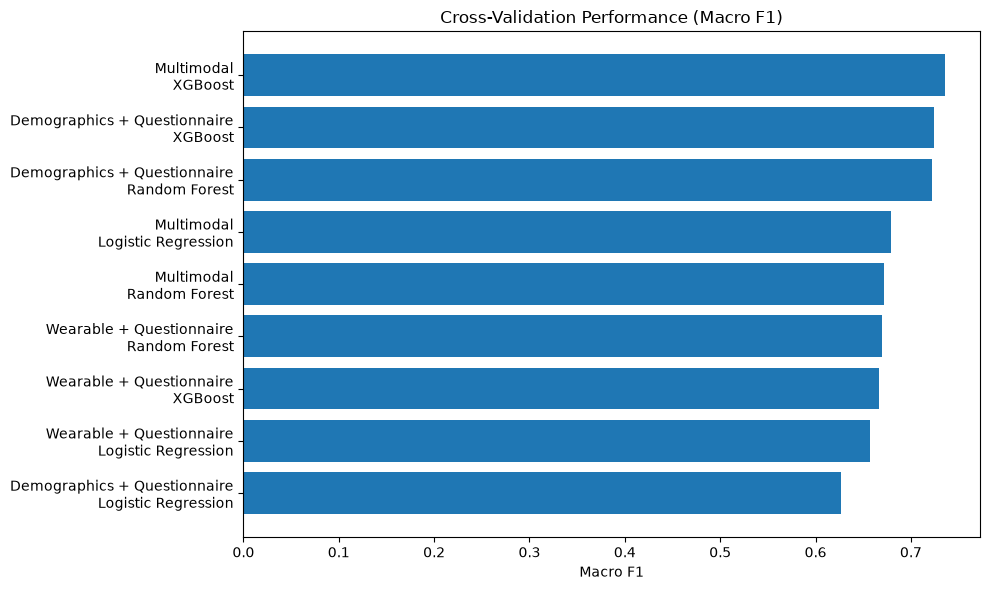

In [38]:
# Figure - Cross-validation Macro F1
plot_data = cross_validation_summary.sort_values(
    "Macro F1",
    ascending=True,
)
fig, ax = plt.subplots(
    figsize=(10,6)
)
labels = (
    plot_data["Dataset"]
    + "\n"
    + plot_data["Model"]
)
ax.barh(
    labels,
    plot_data["Macro F1"],
)
ax.set_xlabel(
    "Macro F1"
)
ax.set_title(
    "Cross-Validation Performance (Macro F1)"
)
plt.tight_layout()
outputs.save_figure(
    fig,
    "11b_cross_validation_macro_f1.png",
)
plt.show()

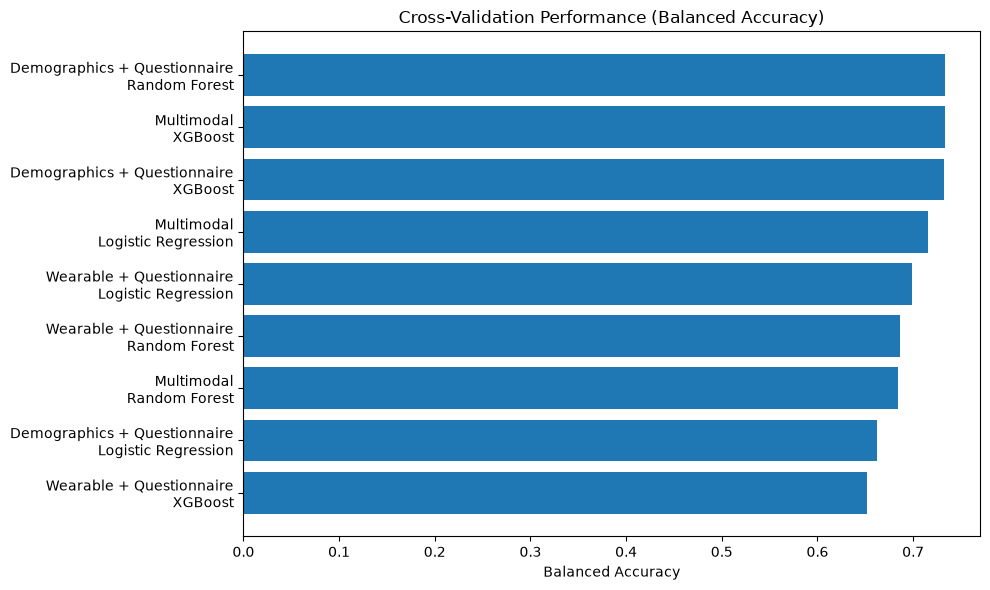

In [39]:
# Figure - Cross-validation Balanced Accuracy
plot_data = cross_validation_summary.sort_values(
    "Balanced Accuracy",
    ascending=True,
)
fig, ax = plt.subplots(
    figsize=(10,6)
)
labels = (
    plot_data["Dataset"]
    + "\n"
    + plot_data["Model"]
)
ax.barh(
    labels,
    plot_data["Balanced Accuracy"],
)
ax.set_xlabel(
    "Balanced Accuracy"
)
ax.set_title(
    "Cross-Validation Performance (Balanced Accuracy)"
)
plt.tight_layout()
outputs.save_figure(
    fig,
    "11b_cross_validation_balanced_accuracy.png",
)
plt.show()

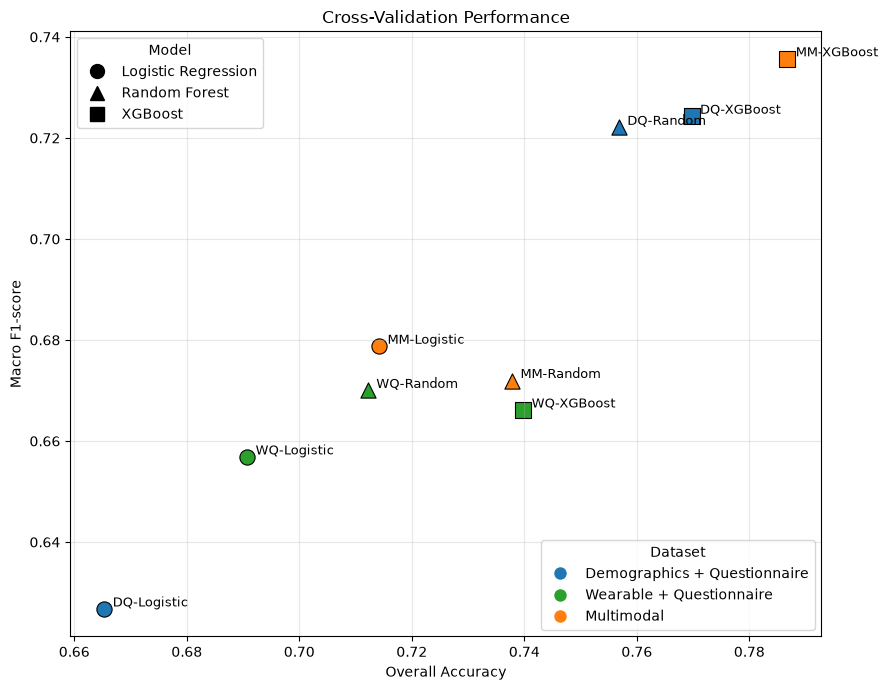

In [40]:
# Figure - Macro F1 vs Accuracy
fig, ax = plt.subplots(
    figsize=(9, 7)
)
dataset_colors = {
    "Demographics + Questionnaire": "#1f77b4",
    "Wearable + Questionnaire": "#2ca02c",
    "Multimodal": "#ff7f0e",
}
model_markers = {
    "Logistic Regression": "o",
    "Random Forest": "^",
    "XGBoost": "s",
}
dataset_short = {
    "Demographics + Questionnaire": "DQ",
    "Wearable + Questionnaire": "WQ",
    "Multimodal": "MM",
}
for _, row in cross_validation_summary.iterrows():
    ax.scatter(

        row["Accuracy"],

        row["Macro F1"],

        color=dataset_colors[row["Dataset"]],

        marker=model_markers[row["Model"]],

        s=120,

        edgecolor="black",

        linewidth=0.8,

    )

    ax.text(

        row["Accuracy"] + 0.0015,

        row["Macro F1"] + 0.0005,

        f"{dataset_short[row['Dataset']]}-{row['Model'].split()[0]}",

        fontsize=9,

    )

# Legend for datasets
dataset_handles = [

    plt.Line2D(

        [0],

        [0],

        marker="o",

        color="w",

        markerfacecolor=color,

        markersize=10,

        label=name,

    )

    for name, color in dataset_colors.items()

]

# Legend for models
model_handles = [

    plt.Line2D(

        [0],

        [0],

        marker=marker,

        color="black",

        linestyle="",

        markersize=10,

        label=name,

    )

    for name, marker in model_markers.items()

]

legend1 = ax.legend(

    handles=dataset_handles,

    title="Dataset",

    loc="lower right",

)

ax.add_artist(legend1)

ax.legend(

    handles=model_handles,

    title="Model",

    loc="upper left",

)

ax.set_xlabel("Overall Accuracy")

ax.set_ylabel("Macro F1-score")

ax.set_title("Cross-Validation Performance")

ax.grid(
    alpha=0.3,
)

plt.tight_layout()
outputs.save_figure(
    fig,
    "11b_macro_f1_vs_accuracy.png",
)
plt.show()

## 8. Model Stability Analysis
Model selection should not rely solely on average predictive performance. Therefore, the stability of each tuned model was evaluated using the cross-validation results obtained from the optimal hyperparameter configuration.

For each model, the mean Macro F1-score, standard deviation, minimum fold performance, maximum fold performance, and coefficient of variation were calculated. These statistics provide insight into the consistency and robustness of each classifier across the validation folds.

In [28]:
# Model stability analysis
stability_summary = []
for (dataset, model), cv_results in cv_results_tables.items():
    best_index = cv_results[
        "mean_test_macro_f1"
    ].idxmax()
    fold_scores = [
        cv_results.loc[
            best_index,
            f"split{i}_test_macro_f1",
        ]
        for i in range(5)
    ]
    mean_macro_f1 = cv_results.loc[
        best_index,
        "mean_test_macro_f1",
    ]
    std_macro_f1 = cv_results.loc[
        best_index,
        "std_test_macro_f1",
    ]
    stability_summary.append(
        {
            "Dataset": dataset,
            "Model": model,
            "Macro F1": mean_macro_f1,
            "Standard Deviation": std_macro_f1,
            "Minimum Fold":
                np.min(fold_scores),
            "Maximum Fold":
                np.max(fold_scores),
            "Coefficient of Variation (%)":
                (std_macro_f1 / mean_macro_f1) * 100,
        }
    )
stability_summary = pd.DataFrame(
    stability_summary
)
stability_summary = stability_summary.sort_values(
    "Macro F1",
    ascending=False,
)

display(stability_summary)

,Dataset,Model,Macro F1,Standard Deviation,Minimum Fold,Maximum Fold,Coefficient of Variation (%)
8,Multimodal,XGBoost,0.735663,0.047483,0.648407,0.786611,6.454516
2,Demographics + Questionnaire,XGBoost,0.724288,0.049234,0.653126,0.800547,6.797618
1,Demographics + Questionnaire,Random Forest,0.722090,0.041401,0.669643,0.791036,5.733439
6,Multimodal,Logistic Regression,0.678752,0.037340,0.640566,0.738306,5.501330
7,Multimodal,Random Forest,0.671973,0.028858,0.643404,0.722222,4.294461
4,Wearable + Questionnaire,Random Forest,0.670013,0.025847,0.627706,0.706988,3.857717
5,Wearable + Questionnaire,XGBoost,0.666134,0.014931,0.644000,0.684594,2.241504
3,Wearable + Questionnaire,Logistic Regression,0.656841,0.026230,0.617834,0.691901,3.993321
0,Demographics + Questionnaire,Logistic Regression,0.626747,0.030357,0.574105,0.659432,4.843599


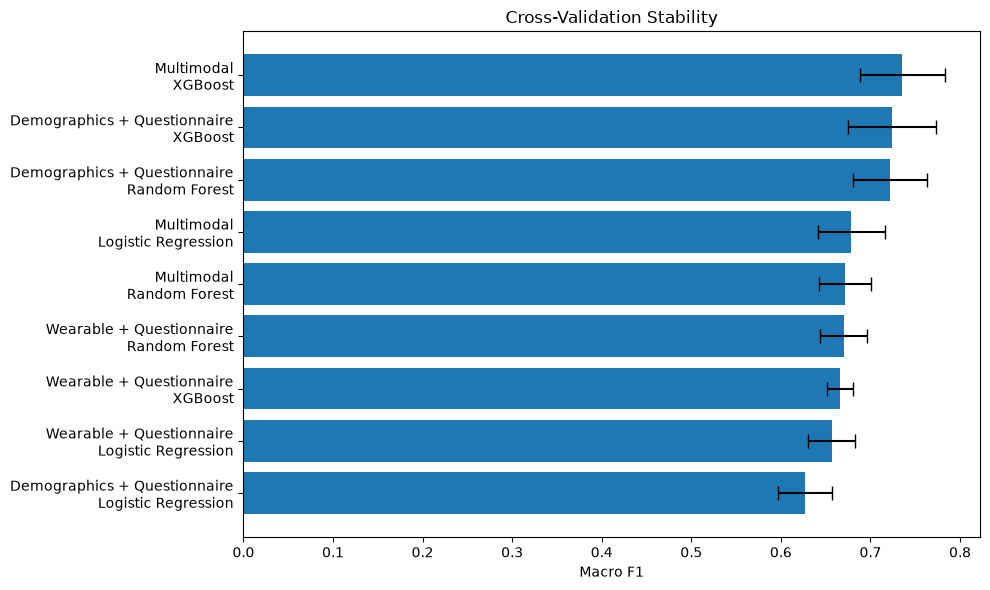

In [33]:
# Cross-validation stability
plot_data = stability_summary.sort_values(
    "Macro F1",
    ascending=True,
)

fig, ax = plt.subplots(
    figsize=(10,6)
)

labels = (

    plot_data["Dataset"]

    + "\n"

    + plot_data["Model"]

)

ax.barh(

    labels,

    plot_data["Macro F1"],

    xerr=plot_data["Standard Deviation"],

    capsize=5,

)

ax.set_xlabel(
    "Macro F1"
)

ax.set_title(
    "Cross-Validation Stability"
)

plt.tight_layout()

outputs.save_figure(
    fig,
    "cross_validation_stability.png",
)

plt.show()

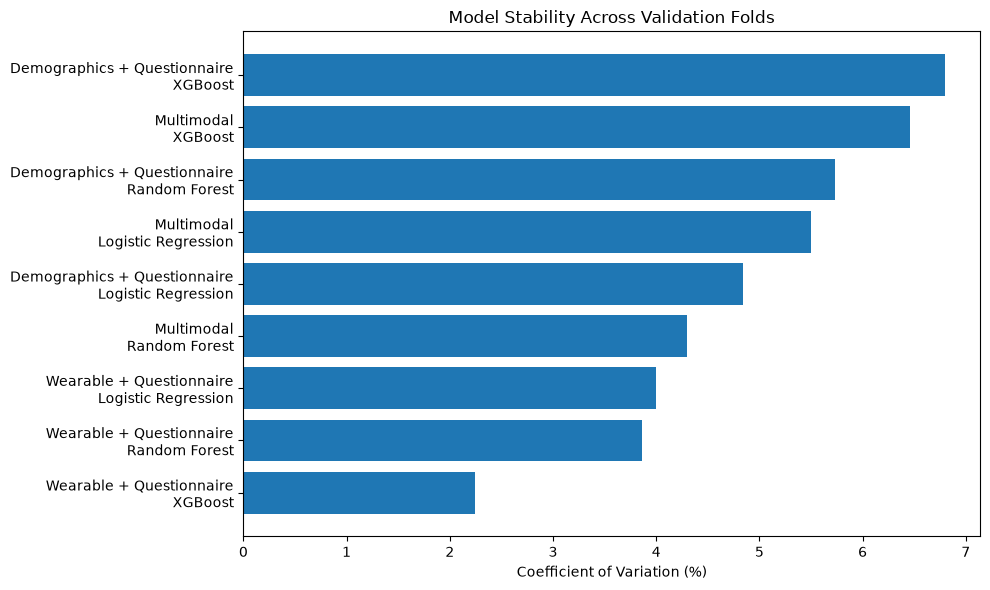

In [34]:
# Coefficient of variation
plot_data = stability_summary.sort_values(
    "Coefficient of Variation (%)"
)

fig, ax = plt.subplots(
    figsize=(10,6)
)

labels = (

    plot_data["Dataset"]

    + "\n"

    + plot_data["Model"]

)

ax.barh(

    labels,

    plot_data["Coefficient of Variation (%)"],

)

ax.set_xlabel(
    "Coefficient of Variation (%)"
)

ax.set_title(
    "Model Stability Across Validation Folds"
)

plt.tight_layout()

outputs.save_figure(
    fig,
    "model_stability_coefficient_variation.png",
)

plt.show()

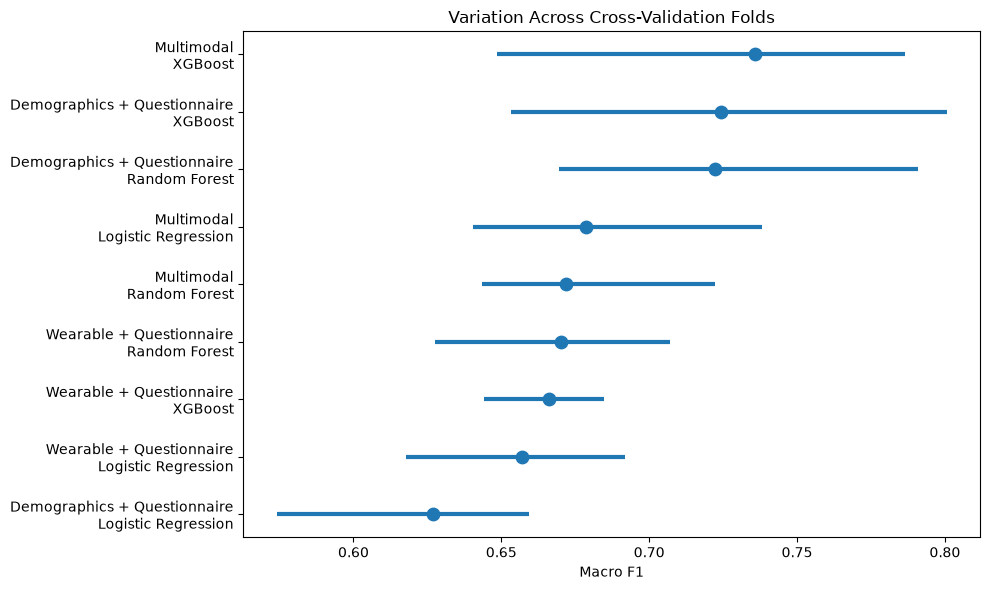

In [35]:
# Fold performance range
plot_data = stability_summary.sort_values(
    "Macro F1"
)
fig, ax = plt.subplots(
    figsize=(10,6)
)

y = np.arange(len(plot_data))

ax.hlines(

    y,

    plot_data["Minimum Fold"],

    plot_data["Maximum Fold"],

    linewidth=3,

)

ax.scatter(

    plot_data["Macro F1"],

    y,

    s=80,

)

ax.set_yticks(y)

ax.set_yticklabels(

    plot_data["Dataset"]

    + "\n"

    + plot_data["Model"]

)

ax.set_xlabel(
    "Macro F1"
)

ax.set_title(
    "Variation Across Cross-Validation Folds"
)
plt.tight_layout()

outputs.save_figure(
    fig,
    "cross_validation_fold_range.png",
)

plt.show()

In [32]:
# Save stability summary
outputs.save_table(
    stability_summary,
    "model_stability_summary.csv",
)
print(
    "Model stability summary saved."
)

Model stability summary saved.


The Multimodal XGBoost classifier achieved the highest average Macro F1-score while maintaining comparable variability to the other leading models. Although the Demographics + Questionnaire Random Forest model exhibited slightly lower variation across folds, its predictive performance remained marginally below that of the Multimodal XGBoost model. Overall, the leading classifiers demonstrated consistent performance across the five validation folds, supporting the robustness of the selected hyperparameter configurations.

## 9. Compute Inference Time & model size

In [44]:
# Measure inference time and model size
import pickle
import time
from pathlib import Path

computational_metrics = []

for (dataset_name, model_name), model in best_models.items():

    dataset = datasets[dataset_name]

    feature_columns = [

        column

        for column in dataset.columns

        if column not in [

            PARTICIPANT_ID_COLUMN,

            TARGET_COLUMN,

            "condition_group",

        ]

    ]

    X = dataset[feature_columns]

    # ----------------------------
    # Inference time
    # ----------------------------

    start = time.perf_counter()

    _ = model.predict(X)

    inference_time = (
        time.perf_counter() - start
    )

    # ----------------------------
    # Serialized model size
    # ----------------------------

    model_bytes = pickle.dumps(model)

    model_size_kb = (
        len(model_bytes) / 1024
    )

    computational_metrics.append(

        {

            "Dataset": dataset_name,

            "Model": model_name,

            "Inference Time (s)": inference_time,

            "Model Size (KB)": model_size_kb,

        }

    )

computational_metrics = pd.DataFrame(
    computational_metrics
)

display(computational_metrics)

,Dataset,Model,Inference Time (s),Model Size (KB)
0,Demographics + Questionnaire,Logistic Regression,0.051736,8.306641
1,Demographics + Questionnaire,Random Forest,0.158073,1778.992188
2,Demographics + Questionnaire,XGBoost,0.051172,642.103516
3,Wearable + Questionnaire,Logistic Regression,0.045745,27.881836
4,Wearable + Questionnaire,Random Forest,0.156620,4421.898438
5,Wearable + Questionnaire,XGBoost,0.045554,675.300781
6,Multimodal,Logistic Regression,0.054163,29.799805
7,Multimodal,Random Forest,0.110875,2114.499023
8,Multimodal,XGBoost,0.035268,352.415039


In [45]:
computational_summary = tuning_summary.merge(

    computational_metrics,

    on=[
        "Dataset",
        "Model",
    ],

    how="left",

)

display(computational_summary)

,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters,Inference Time (s),Model Size (KB)
0,Demographics + Questionnaire,Logistic Regression,0.626747,0.662529,0.665340,0.622194,0.662529,9.579826,"{'classifier__C': 1, 'classifier__max_iter': 1...",0.051736,8.306641
1,Demographics + Questionnaire,Random Forest,0.722090,0.733227,0.756806,0.723475,0.733227,18555.511755,"{'classifier__max_depth': None, 'classifier__m...",0.158073,1778.992188
2,Demographics + Questionnaire,XGBoost,0.724288,0.731754,0.769732,0.742532,0.731754,335.953129,"{'classifier__colsample_bytree': 1.0, 'classif...",0.051172,642.103516
3,Wearable + Questionnaire,Logistic Regression,0.656841,0.699030,0.690734,0.648224,0.699030,10.157386,"{'classifier__C': 0.01, 'classifier__max_iter'...",0.045745,27.881836
4,Wearable + Questionnaire,Random Forest,0.670013,0.685916,0.712194,0.664492,0.685916,2745.682761,"{'classifier__max_depth': None, 'classifier__m...",0.156620,4421.898438
5,Wearable + Questionnaire,XGBoost,0.666134,0.652258,0.739808,0.716689,0.652258,1955.609101,"{'classifier__colsample_bytree': 0.8, 'classif...",0.045554,675.300781
6,Multimodal,Logistic Regression,0.678752,0.715979,0.714184,0.673058,0.715979,13.519290,"{'classifier__C': 0.01, 'classifier__max_iter'...",0.054163,29.799805
7,Multimodal,Random Forest,0.671973,0.684081,0.737817,0.695521,0.684081,2319.699832,"{'classifier__max_depth': None, 'classifier__m...",0.110875,2114.499023
8,Multimodal,XGBoost,0.735663,0.733219,0.786754,0.779369,0.733219,1485.507163,"{'classifier__colsample_bytree': 1.0, 'classif...",0.035268,352.415039


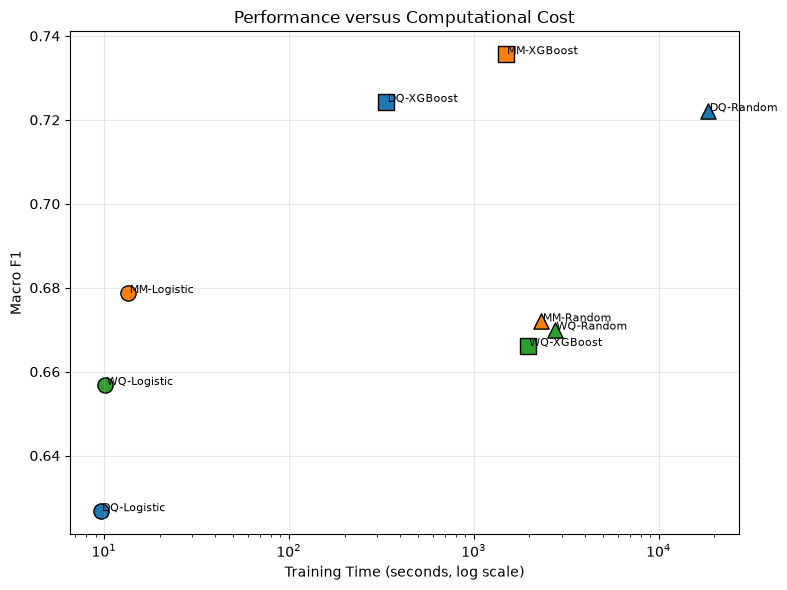

In [47]:
# Performance vs computational cost
fig, ax = plt.subplots(
    figsize=(8,6)
)

dataset_colors = {
    "Demographics + Questionnaire": "#1f77b4",
    "Wearable + Questionnaire": "#2ca02c",
    "Multimodal": "#ff7f0e",
}

model_markers = {
    "Logistic Regression": "o",
    "Random Forest": "^",
    "XGBoost": "s",
}

dataset_short = {
    "Demographics + Questionnaire": "DQ",
    "Wearable + Questionnaire": "WQ",
    "Multimodal": "MM",
}

for _, row in computational_summary.iterrows():

    ax.scatter(

        row["Training Time (s)"],

        row["Macro F1"],

        color=dataset_colors[row["Dataset"]],

        marker=model_markers[row["Model"]],

        s=120,

        edgecolor="black",

    )

    ax.text(

        row["Training Time (s)"] * 1.02,

        row["Macro F1"],

        f"{dataset_short[row['Dataset']]}-{row['Model'].split()[0]}",

        fontsize=8,

    )

ax.set_xscale("log")

ax.set_xlabel(
    "Training Time (seconds, log scale)"
)

ax.set_ylabel(
    "Macro F1"
)

ax.set_title(
    "Performance versus Computational Cost"
)

ax.grid(alpha=0.3)

plt.tight_layout()

outputs.save_figure(
    fig,
    "11b_performance_vs_training_time.png",
)

plt.show()

Logistic Regression required the shortest training time and produced the smallest serialized models, although predictive performance was consistently lower than the tree-based classifiers. Random Forest achieved competitive predictive performance but required substantially longer optimization times due to the large hyperparameter search space. XGBoost provided the strongest balance between predictive performance and computational efficiency, particularly for the Multimodal dataset, where it achieved the highest Macro F1-score while maintaining relatively small model size and low inference latency.

## 10.  Candidate Model Shortlist
The final model candidates were selected by jointly considering predictive performance, stability across validation folds, computational efficiency, and model complexity.

Rather than selecting the classifier with the highest predictive metric alone, models were evaluated according to the following criteria:

- Macro F1-score (primary metric)
- Balanced Accuracy
- Cross-validation stability
- Training time
- Inference time
- Model size
- Model interpretability

The highest-ranked models were retained for the explainability, calibration, and error analysis performed during the following stage of the project.

In [48]:
# Final model comparison
final_model_scorecard = computational_summary.merge(
    stability_summary[
        [
            "Dataset",
            "Model",
            "Standard Deviation",
            "Coefficient of Variation (%)",
        ]
    ],

    on=[
        "Dataset",
        "Model",
    ],

)

final_model_scorecard = final_model_scorecard.sort_values(

    by=[
        "Macro F1",
        "Balanced Accuracy",
    ],

    ascending=False,

)

display(final_model_scorecard)

,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters,Inference Time (s),Model Size (KB),Standard Deviation,Coefficient of Variation (%)
8,Multimodal,XGBoost,0.735663,0.733219,0.786754,0.779369,0.733219,1485.507163,"{'classifier__colsample_bytree': 1.0, 'classif...",0.035268,352.415039,0.047483,6.454516
2,Demographics + Questionnaire,XGBoost,0.724288,0.731754,0.769732,0.742532,0.731754,335.953129,"{'classifier__colsample_bytree': 1.0, 'classif...",0.051172,642.103516,0.049234,6.797618
1,Demographics + Questionnaire,Random Forest,0.722090,0.733227,0.756806,0.723475,0.733227,18555.511755,"{'classifier__max_depth': None, 'classifier__m...",0.158073,1778.992188,0.041401,5.733439
6,Multimodal,Logistic Regression,0.678752,0.715979,0.714184,0.673058,0.715979,13.519290,"{'classifier__C': 0.01, 'classifier__max_iter'...",0.054163,29.799805,0.037340,5.501330
7,Multimodal,Random Forest,0.671973,0.684081,0.737817,0.695521,0.684081,2319.699832,"{'classifier__max_depth': None, 'classifier__m...",0.110875,2114.499023,0.028858,4.294461
4,Wearable + Questionnaire,Random Forest,0.670013,0.685916,0.712194,0.664492,0.685916,2745.682761,"{'classifier__max_depth': None, 'classifier__m...",0.156620,4421.898438,0.025847,3.857717
5,Wearable + Questionnaire,XGBoost,0.666134,0.652258,0.739808,0.716689,0.652258,1955.609101,"{'classifier__colsample_bytree': 0.8, 'classif...",0.045554,675.300781,0.014931,2.241504
3,Wearable + Questionnaire,Logistic Regression,0.656841,0.699030,0.690734,0.648224,0.699030,10.157386,"{'classifier__C': 0.01, 'classifier__max_iter'...",0.045745,27.881836,0.026230,3.993321
0,Demographics + Questionnaire,Logistic Regression,0.626747,0.662529,0.665340,0.622194,0.662529,9.579826,"{'classifier__C': 1, 'classifier__max_iter': 1...",0.051736,8.306641,0.030357,4.843599


In [49]:
# Final model shortlist
final_shortlist = final_model_scorecard.head(3).copy()
final_shortlist.insert(
    0,
    "Rank",
    range(
        1,
        len(final_shortlist)+1,
    ),
)
display(final_shortlist)

,Rank,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters,Inference Time (s),Model Size (KB),Standard Deviation,Coefficient of Variation (%)
8,1,Multimodal,XGBoost,0.735663,0.733219,0.786754,0.779369,0.733219,1485.507163,"{'classifier__colsample_bytree': 1.0, 'classif...",0.035268,352.415039,0.047483,6.454516
2,2,Demographics + Questionnaire,XGBoost,0.724288,0.731754,0.769732,0.742532,0.731754,335.953129,"{'classifier__colsample_bytree': 1.0, 'classif...",0.051172,642.103516,0.049234,6.797618
1,3,Demographics + Questionnaire,Random Forest,0.722090,0.733227,0.756806,0.723475,0.733227,18555.511755,"{'classifier__max_depth': None, 'classifier__m...",0.158073,1778.992188,0.041401,5.733439


In [50]:
outputs.save_table(

    final_shortlist,

    "11b_final_model_shortlist.csv",

)

print(
    "Final model shortlist saved."
)

Final model shortlist saved.
